# Lab 4

Description of lab:

Visualizations and transformations. Multi-layered charts, log-linear and log-log transformations, use seaborn, long-wide-long transformation. Multiple graphs in same, two ways.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
pwt = pd.read_csv("https://jmaurit.github.io/anv_statistikk/data/pwt100.csv", sep=";", decimal=",")

In [3]:
pwt.head()

,countrycode,country,currency_unit,year,rgdpe,rgdpo,pop,emp,avh,hc,ccon,cda,cgdpe,cgdpo,cn,ck,ctfp,cwtfp,rgdpna,rconna,rdana,rnna,rkna,rtfpna,rwtfpna,labsh,irr,delta,xr,pl_con,pl_da,pl_gdpo,i_cig,i_xm,i_xr,i_outlier,i_irr,cor_exp,statcap,csh_c,csh_i,csh_g,csh_x,csh_m,csh_r,pl_c,pl_i,pl_g,pl_x,pl_m,pl_n,pl_k
0,ABW,Aruba,Aruban Guilder,1950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,Aruba,Aruban Guilder,1951,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,Aruba,Aruban Guilder,1952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,Aruba,Aruban Guilder,1953,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,Aruba,Aruban Guilder,1954,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
pwt['rgdpe_per_pers'] = pwt['rgdpe'] / pwt['pop']

In [5]:
pwt2019 = pwt.loc[pwt['year'] == 2019].copy()

In [6]:
pwt2019.dropna(inplace = True, subset = ['hc'])

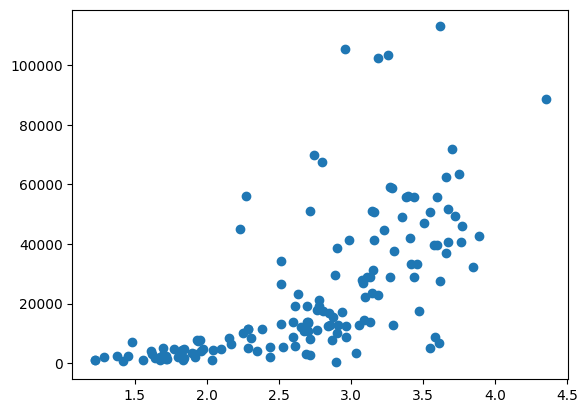

In [7]:
plt.scatter(x = pwt2019['hc'], y = pwt2019['rgdpe_per_pers'])
plt.show()

In [9]:
from cycler import cycler

plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams["axes.labelsize"]= 12
plt.rcParams["figure.facecolor"] = "#f2f2f2"
# plt.rcParams['figure.savefig.dpi'] = 100
plt.rcParams['savefig.edgecolor'] = "#f2f2f2"
plt.rcParams['savefig.facecolor'] ="#f2f2f2"
plt.rcParams["figure.figsize"] = [16, 10]
plt.rcParams['savefig.bbox'] = "tight"
plt.rcParams['font.size'] = 14
greens = ['#66c2a4','#41ae76','#238b45','#006d2c','#00441b']
multi = ['#66c2a4','#1f78b4','#a6cee3','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f']
plt.rcParams["axes.prop_cycle"] = cycler(color = multi)

Text(0, 0.5, 'Real GDP Per Person')

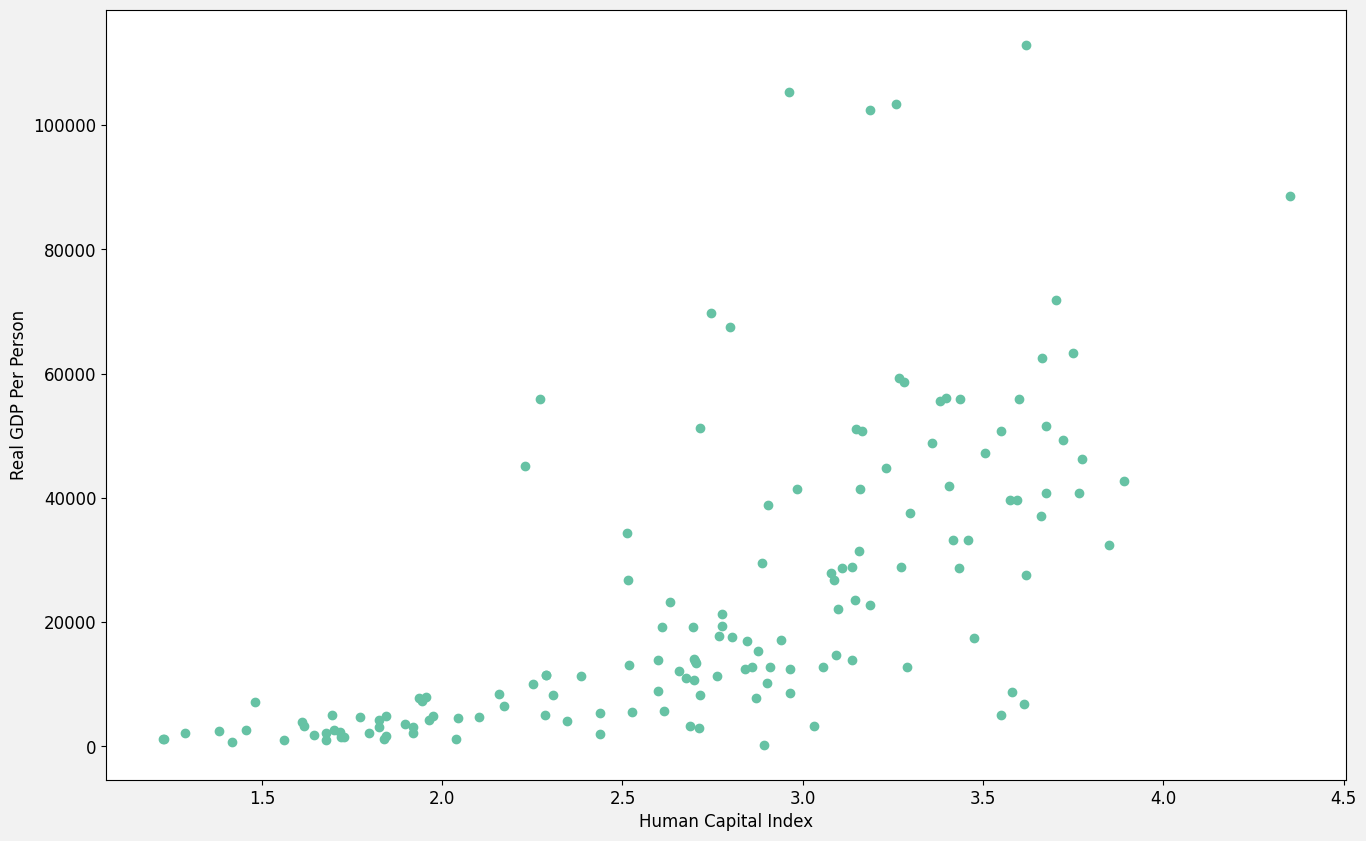

In [10]:
fig, ax = plt.subplots()
ax.scatter(pwt2019['hc'], pwt2019['rgdpe_per_pers'])
ax.set_xlabel('Human Capital Index')
ax.set_ylabel('Real GDP Per Person')

In [11]:
outliers = pwt2019.loc[pwt2019['rgdpe_per_pers'] > 80000, ['hc', 'rgdpe_per_pers', 'country']]
outliers

,hc,rgdpe_per_pers,country
5599,3.185517,102353.631453,Ireland
7209,3.619643,112941.453350,Luxembourg
7349,2.962418,105337.890061,"China, Macao SAR"
9799,3.259456,103445.127287,Qatar
10289,4.351568,88619.305271,Singapore


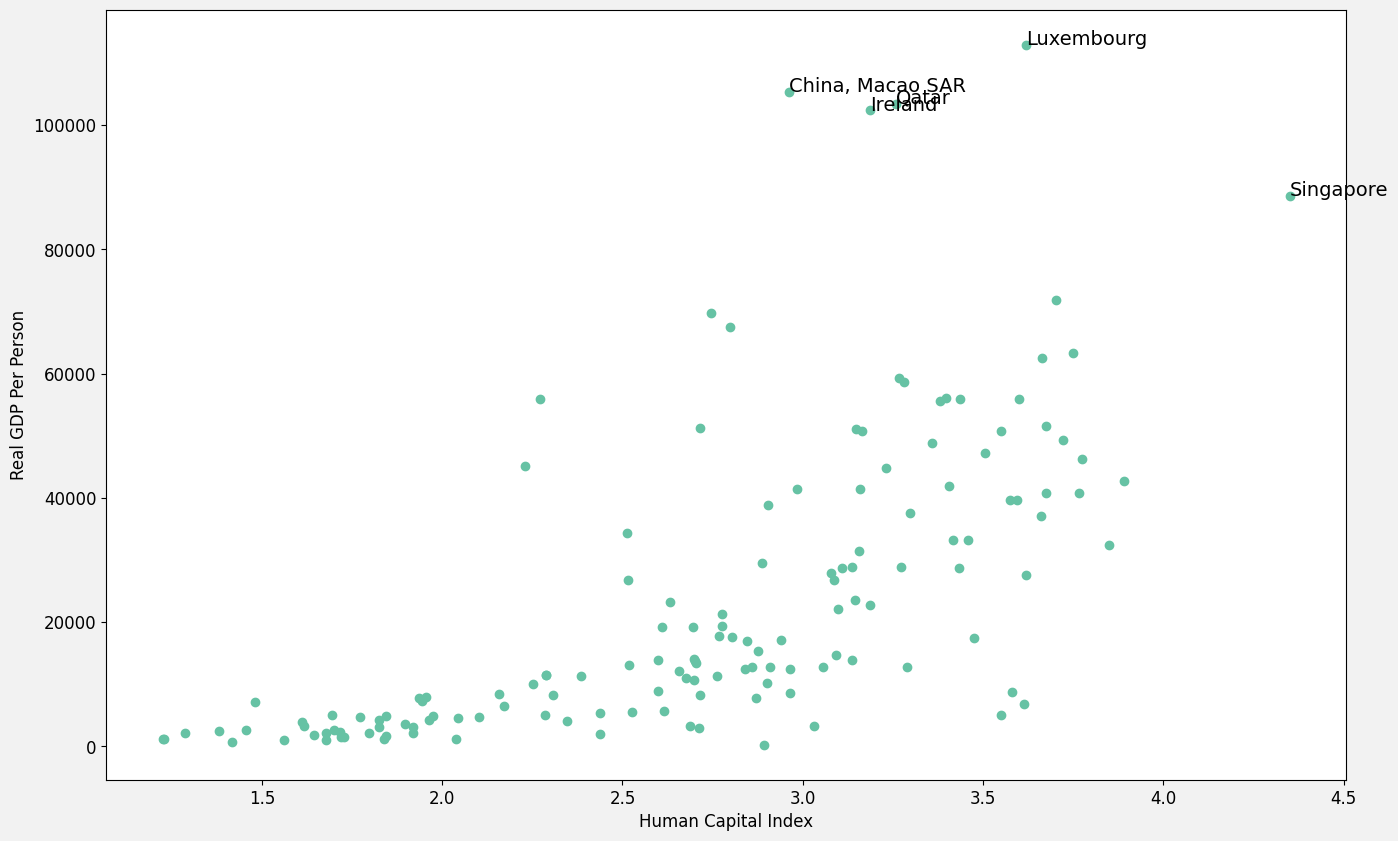

In [12]:
fig, ax = plt.subplots()
ax.scatter(pwt2019['hc'], pwt2019['rgdpe_per_pers'])
ax.set_xlabel('Human Capital Index')
ax.set_ylabel('Real GDP Per Person')
for index, outlier in outliers.iterrows():
    ax.text(outlier['hc'], outlier['rgdpe_per_pers'], outlier['country'])

Using the natural logarithm to transform the data for the purpose of linearizing the relationship and minimizing outliers.

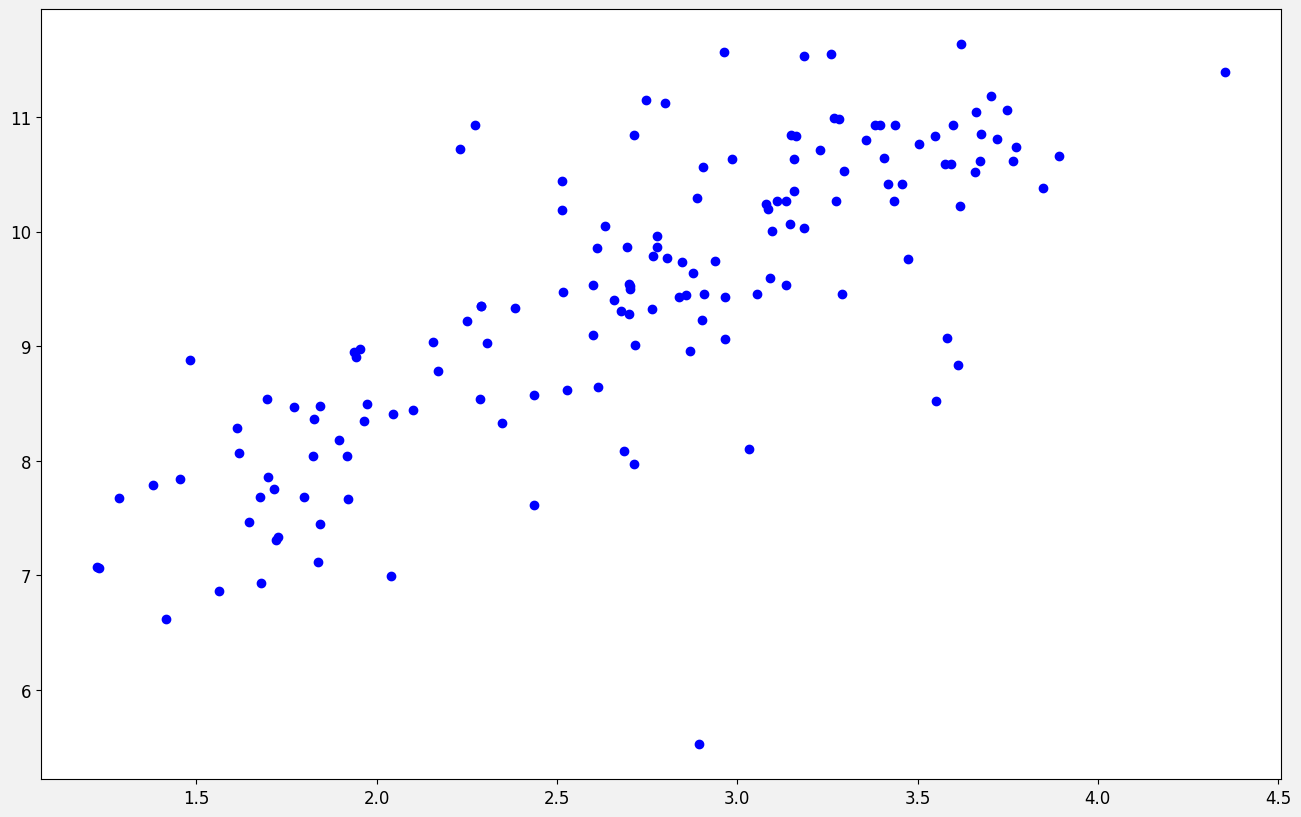

In [14]:
fig, ax = plt.subplots()
ax.scatter(pwt2019['hc'], np.log(pwt2019['rgdpe_per_pers']), color = 'blue')
plt.show()

Now a ln transformation on both axes:

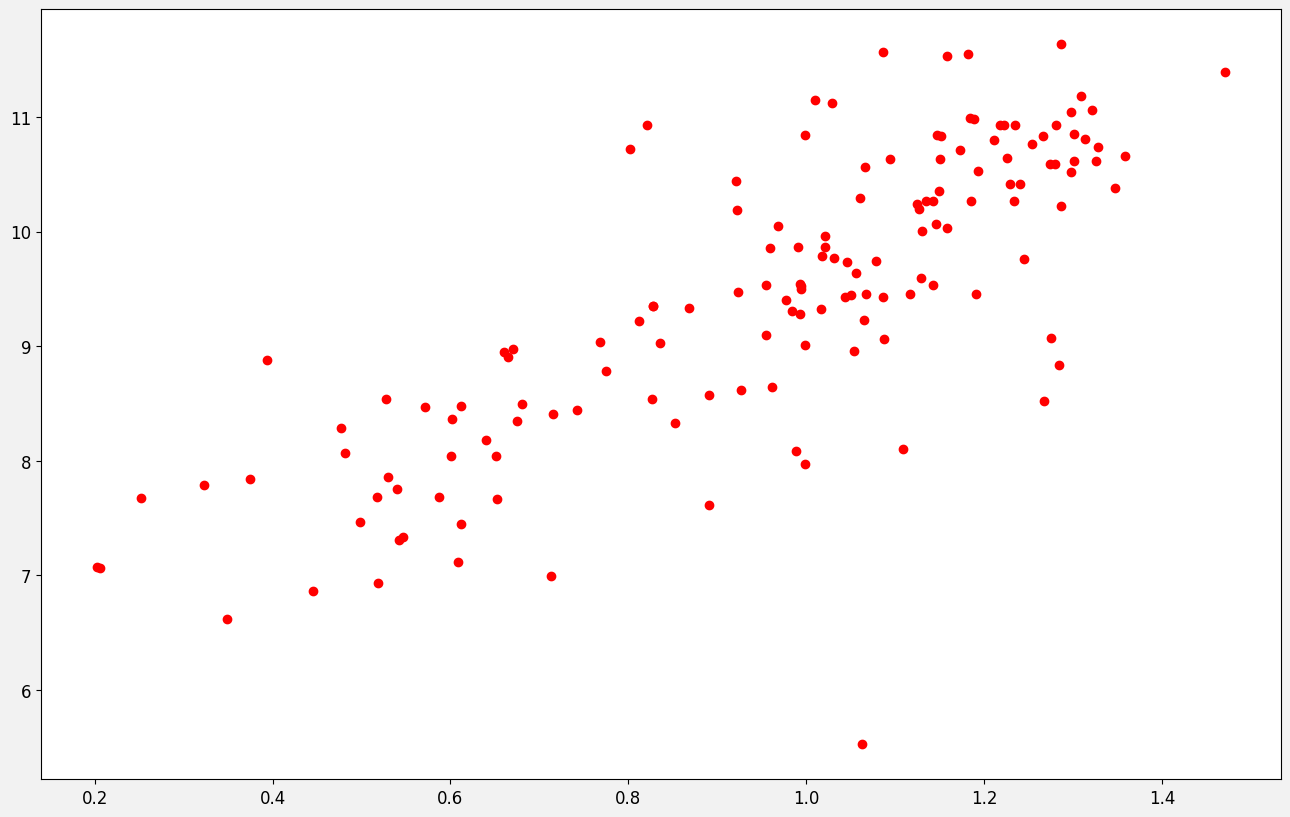

In [15]:
fig, ax = plt.subplots()
ax.scatter(np.log(pwt2019['hc']), np.log(pwt2019['rgdpe_per_pers']), color = 'red')
plt.show()

Making 2d plots represent 3d data.

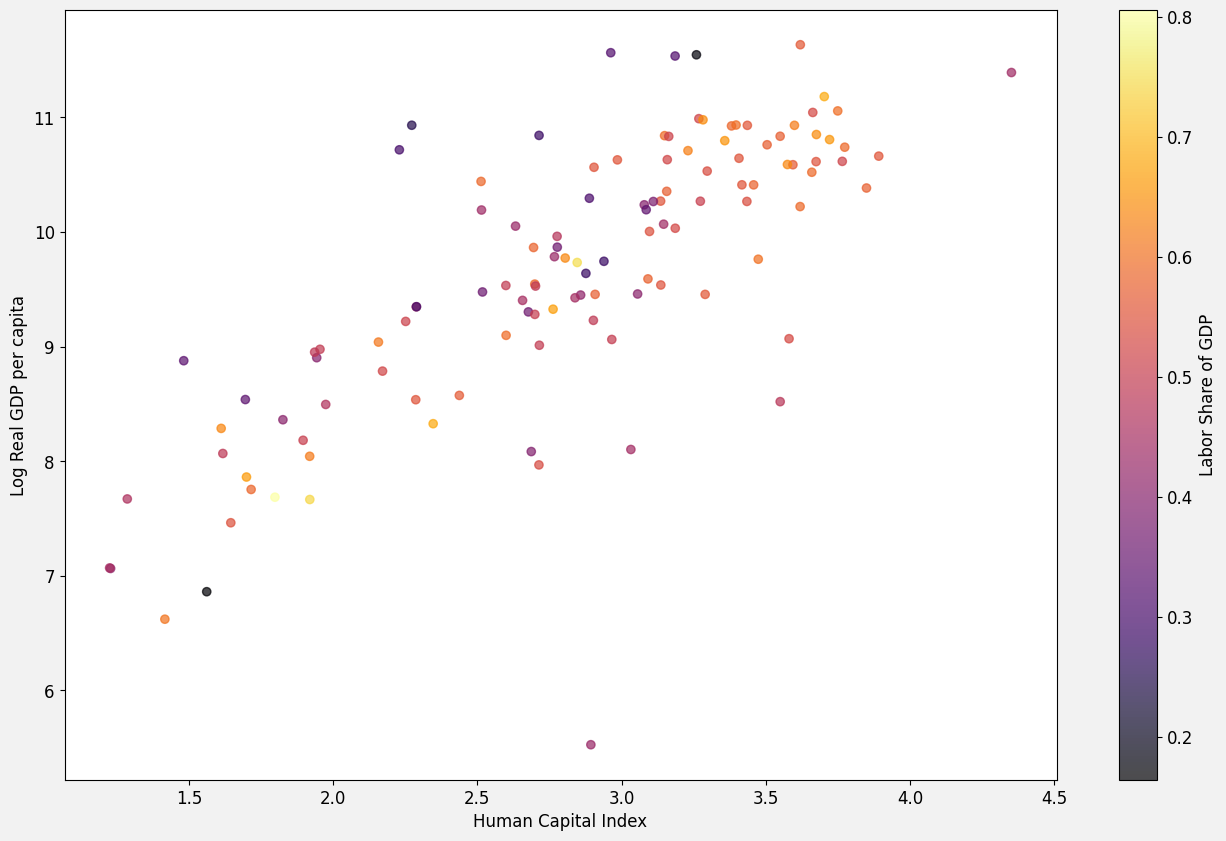

In [27]:
fig, ax = plt.subplots()
s = ax.scatter(pwt2019['hc'], np.log(pwt2019['rgdpe_per_pers']), c = pwt2019['labsh'], cmap = 'inferno', alpha = .7)
ax.set_xlabel('Human Capital Index')
ax.set_ylabel('Log Real GDP per capita')
colorbar = plt.colorbar(s, ax = ax)
colorbar.set_label('Labor Share of GDP')

In [34]:
largeCountries = pwt2019.loc[pwt2019['pop'] > 250, ['hc', 'rgdpe_per_pers', 'country', 'pop']].sort_values(by = ['pop'], ascending = False)
largeCountries

,hc,rgdpe_per_pers,country,pop
2379,2.698987,13988.209097,China,1433.783686
5529,2.171165,6546.714556,India,1366.417754
12179,3.749341,63393.284797,United States,329.064917
5459,2.288165,11471.343129,Indonesia,270.625568


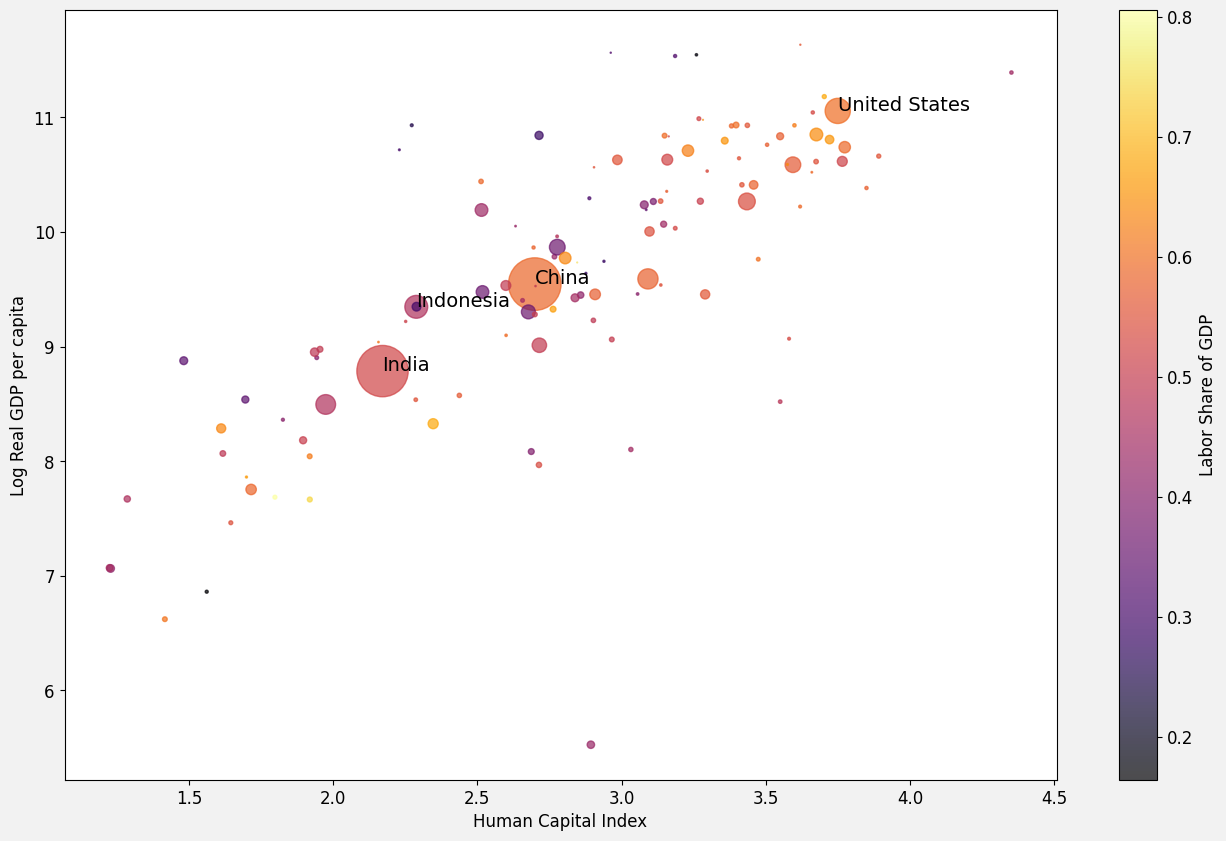

In [41]:
fig, ax = plt.subplots()

s = ax.scatter(pwt2019['hc'], np.log(pwt2019['rgdpe_per_pers']), c = pwt2019['labsh'], cmap = 'inferno', s = pwt2019['pop'], alpha = .7)

for index, country in largeCountries.iterrows():
    ax.text(country['hc'], np.log(country['rgdpe_per_pers']), country['country'])

ax.set_xlabel('Human Capital Index')
ax.set_ylabel('Log Real GDP per capita')

colorbar = plt.colorbar(s, ax = ax)
colorbar.set_label('Labor Share of GDP')

### Some linear regression

In [43]:
import statsmodels.formula.api as smf
import seaborn as sns

In [47]:
fit0 = smf.ols('np.log(rgdpe_per_pers) ~ hc', data = pwt2019).fit()
a = fit0.params.iloc[0]
b = fit0.params.iloc[1]
x = np.linspace(1, 4.5)
fitted = a + b * x

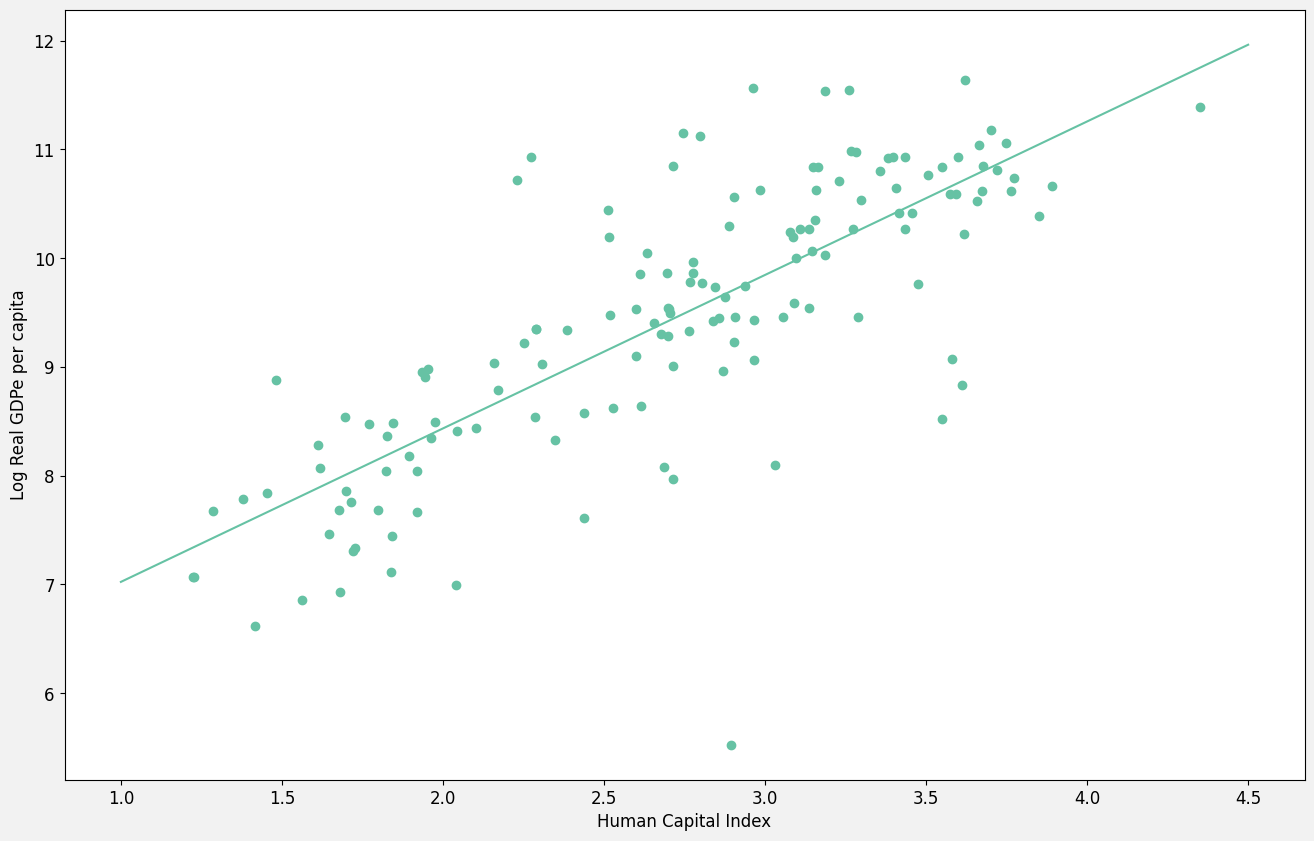

In [49]:
fig, ax = plt.subplots()
ax.scatter(pwt2019['hc'], np.log(pwt2019['rgdpe_per_pers']))
ax.set_xlabel('Human Capital Index')
ax.set_ylabel('Log Real GDPe per capita')
ax.plot(x, fitted, '-')
plt.show()

In [50]:
pwt2019['log_rgdpe_pp'] = np.log(pwt2019['rgdpe_per_pers'])

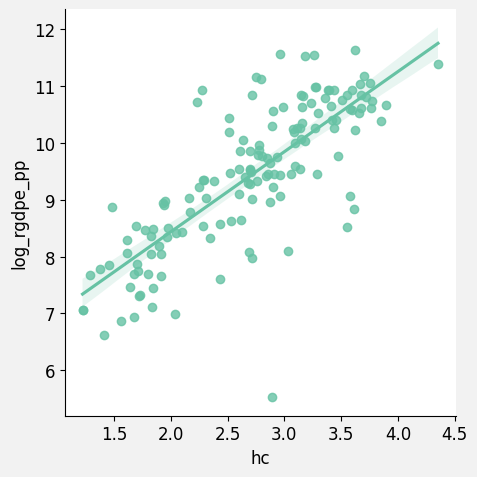

In [58]:
sns.lmplot(x = 'hc', y = 'log_rgdpe_pp', ci = 95, data = pwt2019)
plt.show()

### Faceting

In [59]:
countries = ['Norway', 'Sweden', 'Italy', 'Germany', 'United States', 'China', 'Vietnam', 'Japan', 'Venezuela', 'Argentina']

In [60]:
pwtLim = pwt.loc[pwt['country'].isin(countries)].copy()
pwtLim.dropna(subset = ['rgdpe_per_pers'], inplace = True)
pwtLim.head()

,countrycode,country,currency_unit,year,rgdpe,rgdpo,pop,emp,avh,hc,ccon,cda,cgdpe,cgdpo,cn,ck,ctfp,cwtfp,rgdpna,rconna,rdana,rnna,rkna,rtfpna,rwtfpna,labsh,irr,delta,xr,pl_con,pl_da,pl_gdpo,i_cig,i_xm,i_xr,i_outlier,i_irr,cor_exp,statcap,csh_c,csh_i,csh_g,csh_x,csh_m,csh_r,pl_c,pl_i,pl_g,pl_x,pl_m,pl_n,pl_k,rgdpe_per_pers
350,ARG,Argentina,Argentine Peso,1950,50303.95313,50108.76172,17.091824,6.608833,2034.000000,1.816503,43743.45703,48022.82813,49204.30078,50511.76563,59449.36719,NaN,NaN,NaN,196688.4531,146144.5313,156731.9219,360603.2813,NaN,NaN,NaN,0.441024,0.308121,0.027629,9.160470e-13,0.200356,0.220172,0.214473,Extrapolated,Extrapolated,Estimated,Outlier,Regular,NaN,NaN,0.787090,0.084720,0.078915,0.122540,-0.060423,-0.012842,0.193067,0.422730,0.273050,0.117665,0.107814,0.292420,NaN,2943.158873
351,ARG,Argentina,Argentine Peso,1951,52677.96484,51339.16797,17.457578,6.713252,2037.866753,1.830769,44728.54297,51221.75781,51548.02734,51700.11328,65330.94141,NaN,NaN,NaN,208305.2031,149824.7500,171590.5469,395939.8750,NaN,NaN,NaN,0.441024,0.356293,0.028062,1.155470e-12,0.219622,0.238291,0.237590,Extrapolated,Extrapolated,Estimated,Outlier,Regular,NaN,NaN,0.787292,0.125594,0.077862,0.100497,-0.074776,-0.016469,0.213862,0.366893,0.277869,0.142259,0.118755,0.264830,NaN,3017.484132
352,ARG,Argentina,Argentine Peso,1952,47677.20703,46855.10156,17.815967,6.819321,2041.740856,1.845147,42317.23438,47927.17578,46790.66016,47280.32813,69985.56250,NaN,NaN,NaN,195898.2500,141676.1719,159190.9219,422138.8125,NaN,NaN,NaN,0.441024,0.309781,0.028585,1.388060e-12,0.235866,0.251158,0.248557,Extrapolated,Extrapolated,Estimated,Outlier,Regular,NaN,NaN,0.811196,0.118653,0.083832,0.077847,-0.058380,-0.033148,0.229605,0.366508,0.296447,0.126297,0.130694,0.268225,NaN,2676.094332
353,ARG,Argentina,Argentine Peso,1953,49529.67188,49917.14844,18.168618,6.927065,2045.622325,1.859638,42263.65625,48224.31641,48639.13672,50378.66797,74549.84375,NaN,NaN,NaN,204164.8750,141119.5156,160590.7813,450224.4063,NaN,NaN,NaN,0.441024,0.306920,0.028768,1.497830e-12,0.238649,0.254908,0.246106,Extrapolated,Extrapolated,Estimated,Outlier,Regular,NaN,NaN,0.761823,0.118317,0.077097,0.106709,-0.041785,-0.022161,0.230860,0.370191,0.315614,0.110863,0.102362,0.267306,NaN,2726.111106
354,ARG,Argentina,Argentine Peso,1954,51835.37500,52254.76953,18.517168,7.036511,2049.511172,1.874243,45478.01563,51166.21875,50798.34766,52633.07422,78962.32031,0.005999,0.711535,0.69132,210812.5625,151859.7656,169543.1250,475599.7813,0.128208,1.133463,0.906539,0.441024,0.294267,0.028812,1.603110e-12,0.238442,0.254360,0.245493,Extrapolated,Extrapolated,Estimated,Outlier,Regular,NaN,NaN,0.786910,0.108073,0.077148,0.108594,-0.051525,-0.029199,0.229684,0.381629,0.327768,0.094007,0.093510,0.273750,8.502229,2799.314415


In [63]:
pwtLim['log_rgdpe_pp'] = np.log(pwtLim['rgdpe_per_pers'])

<Axes: xlabel='year'>

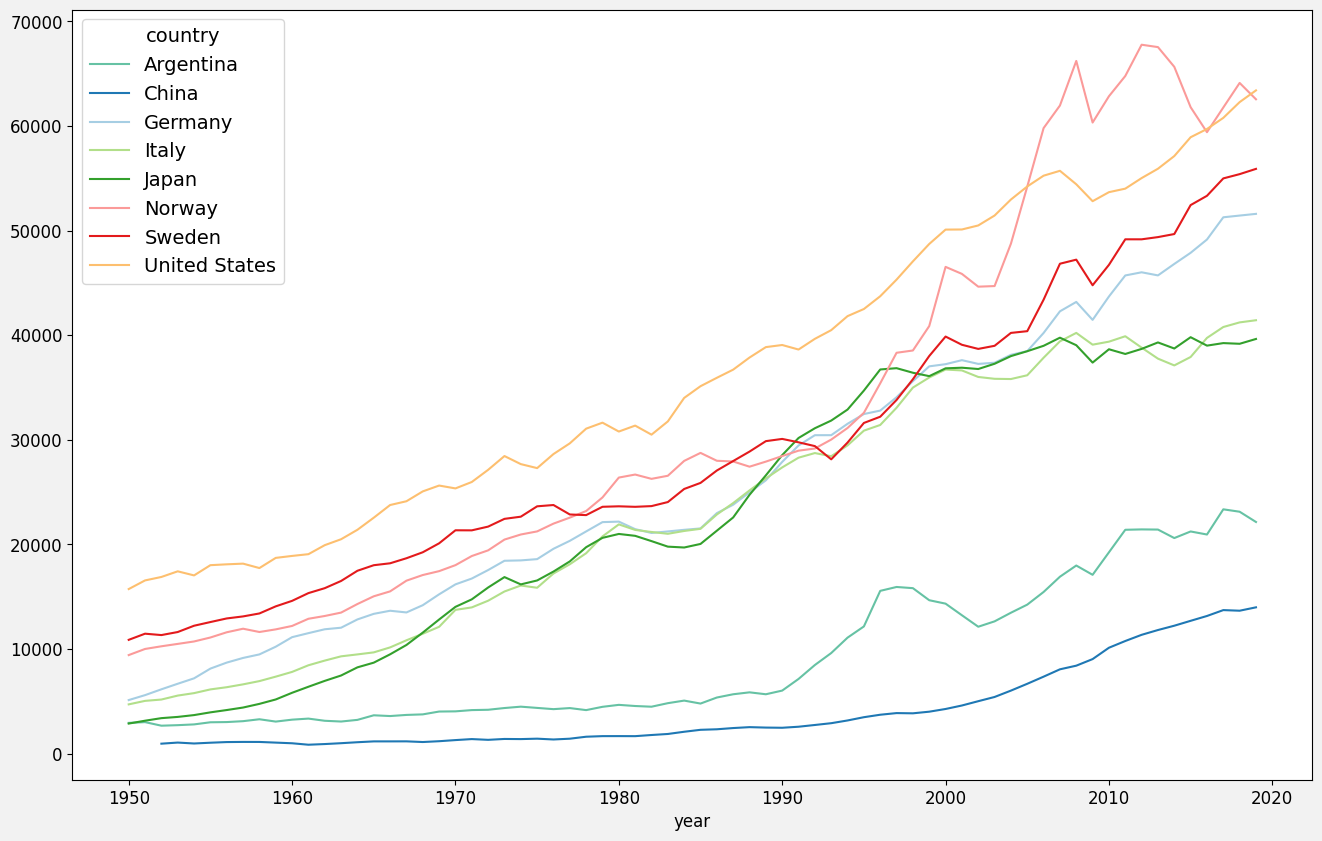

In [69]:
pwtLim.pivot(index = 'year', columns = 'country', values = 'rgdpe_per_pers').plot()

<Axes: xlabel='year'>

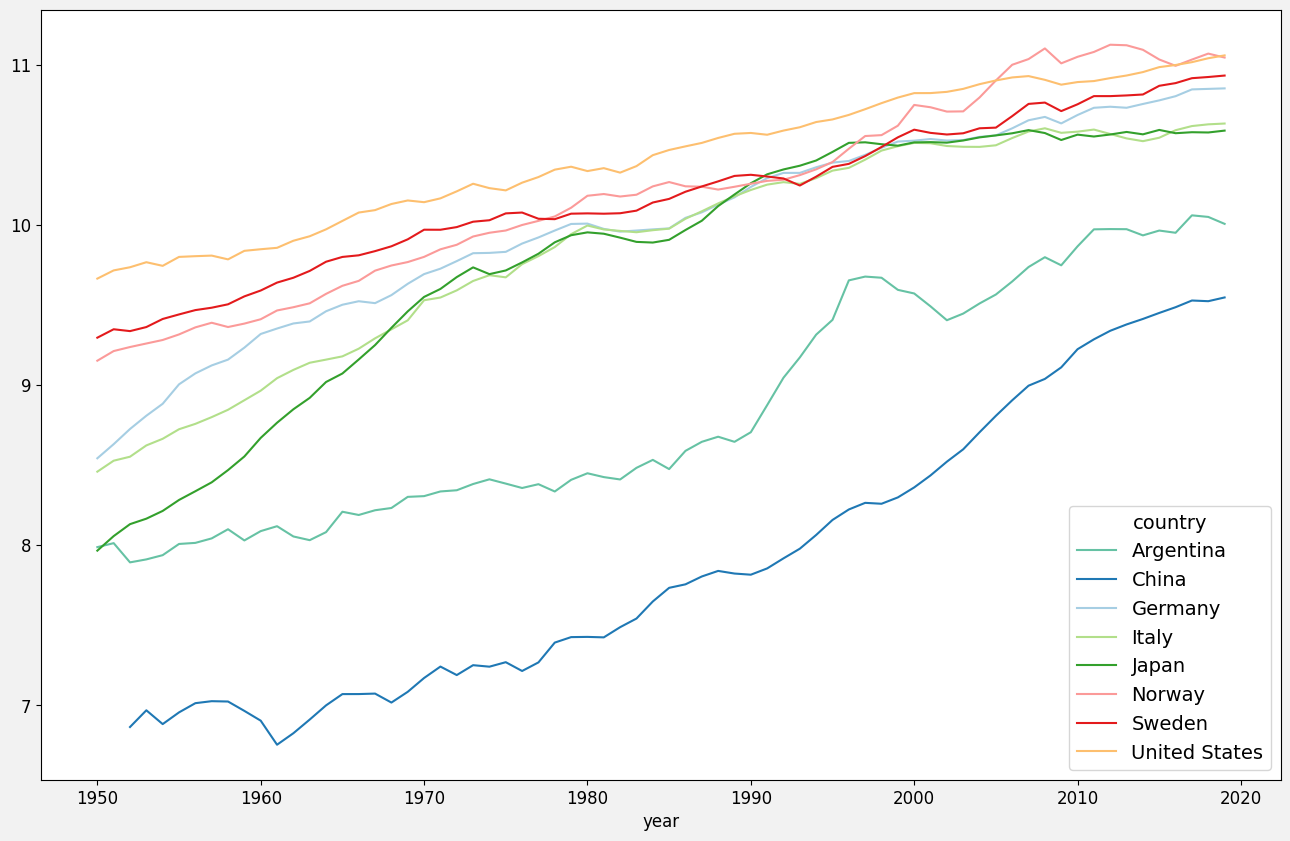

In [70]:
pwtLim.pivot(index = 'year', columns = 'country', values = 'log_rgdpe_pp').plot()

In [71]:
def relativeStart(x):
    return (x / min(x)) * 100

pwtLim['gdp_index'] = pwtLim.groupby('country')['rgdpe_per_pers'].transform(relativeStart)

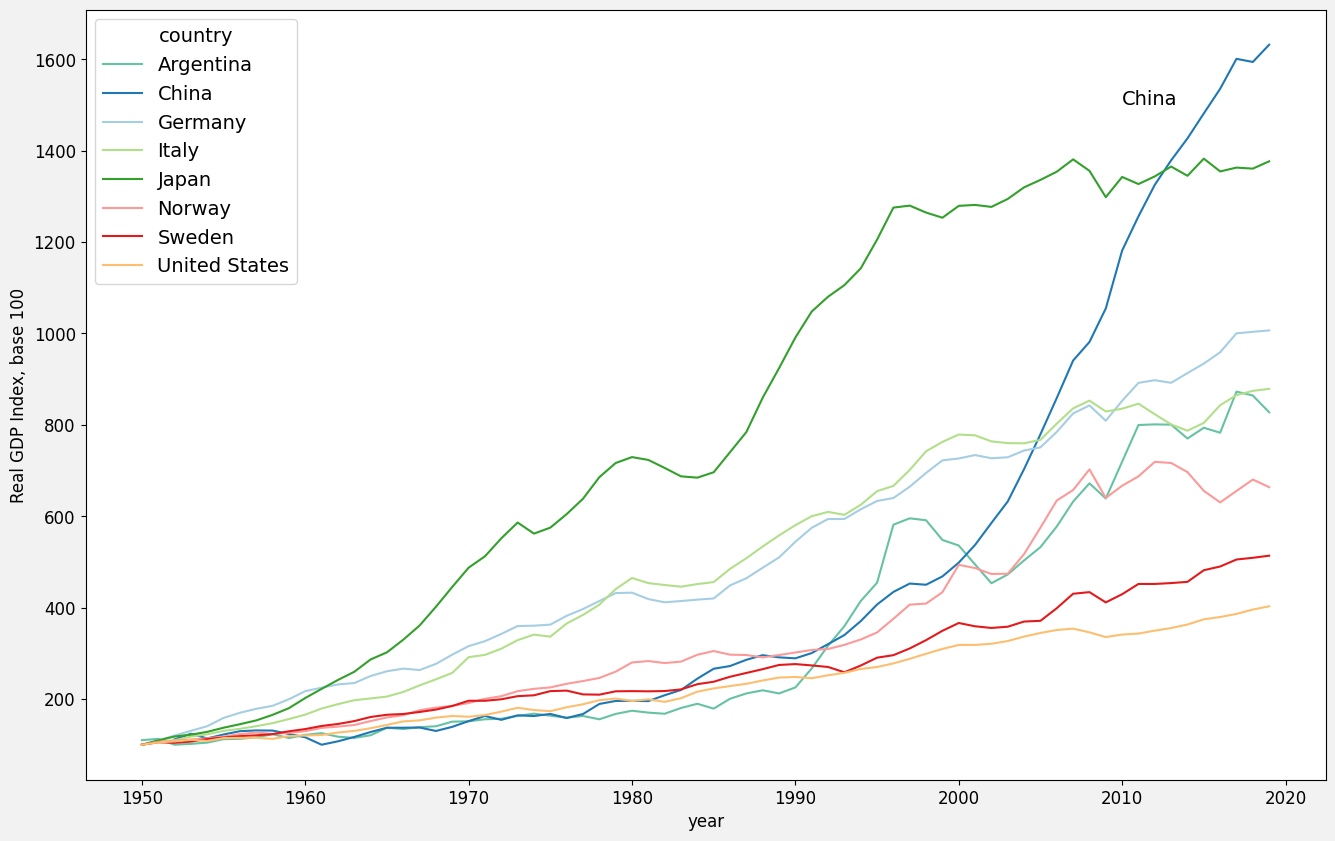

In [74]:
fig, ax = plt.subplots()
pwtLim.pivot(index = 'year', columns = 'country', values = 'gdp_index').plot(ax = ax)
ax.set_ylabel('Real GDP Index, base 100')
ax.text(2010, 1500, 'China')
plt.show()

In [76]:
GDP = pwtLim.pivot(index = 'year', columns = 'country', values = 'rgdpe_per_pers')
GDP.head()

country,Argentina,China,Germany,Italy,Japan,Norway,Sweden,United States
year,,,,,,,,
1950,2943.158873,NaN,5125.100497,4714.265425,2879.177004,9424.347613,10881.212655,15733.918172
1951,3017.484132,NaN,5596.992779,5048.451298,3152.738542,10009.482258,11468.740798,16560.230799
1952,2676.094332,957.433210,6153.230364,5175.559029,3397.109909,10264.624152,11336.588767,16890.197161
1953,2726.111106,1062.740674,6684.230125,5553.697770,3515.269011,10493.160924,11627.835959,17429.463987
1954,2799.314415,975.037985,7202.203591,5788.333844,3689.565269,10725.342092,12229.159738,17039.069441


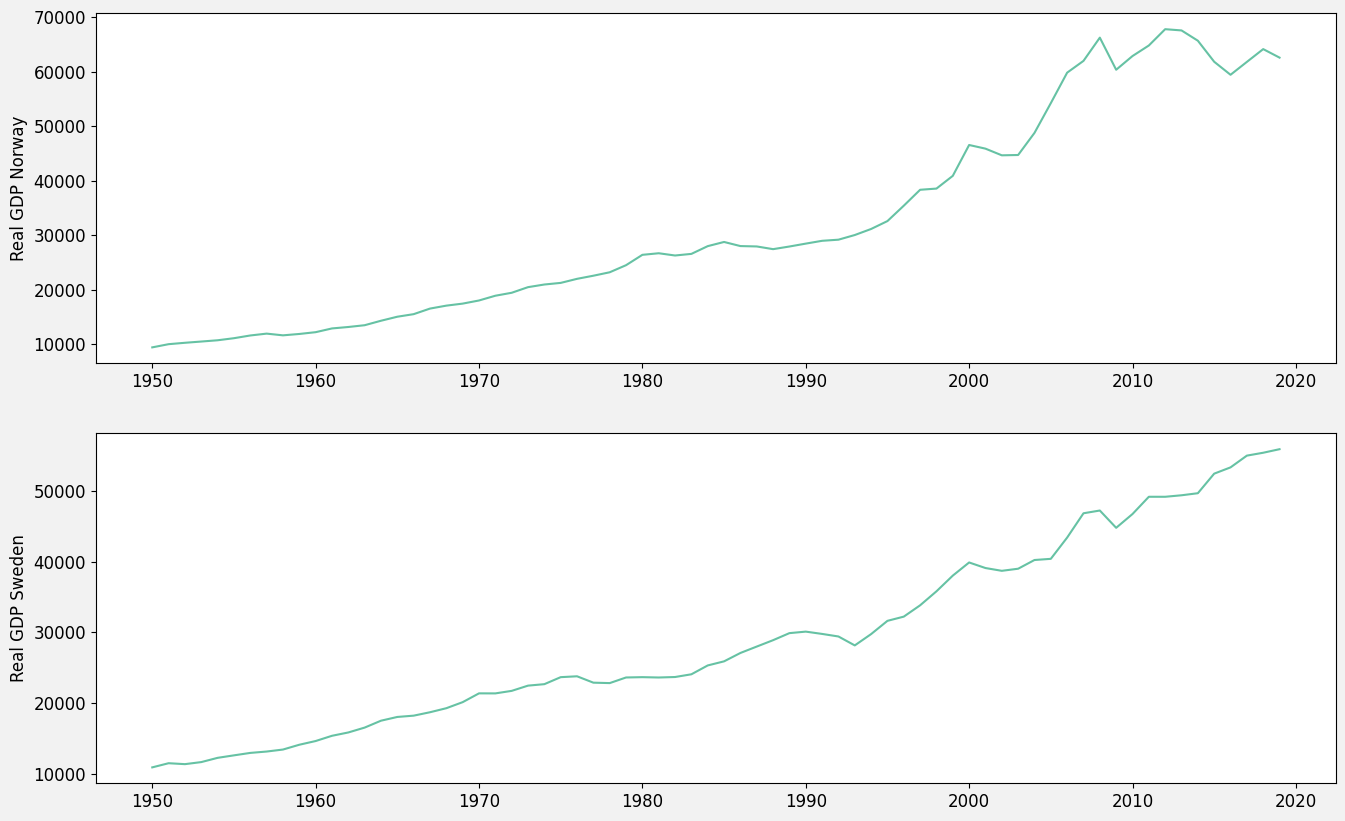

In [78]:
fig, ax = plt.subplots(2)
ax[0].plot(GDP['Norway'])
ax[1].plot(GDP['Sweden'])
ax[0].set_ylabel('Real GDP Norway')
ax[1].set_ylabel('Real GDP Sweden')
plt.show()

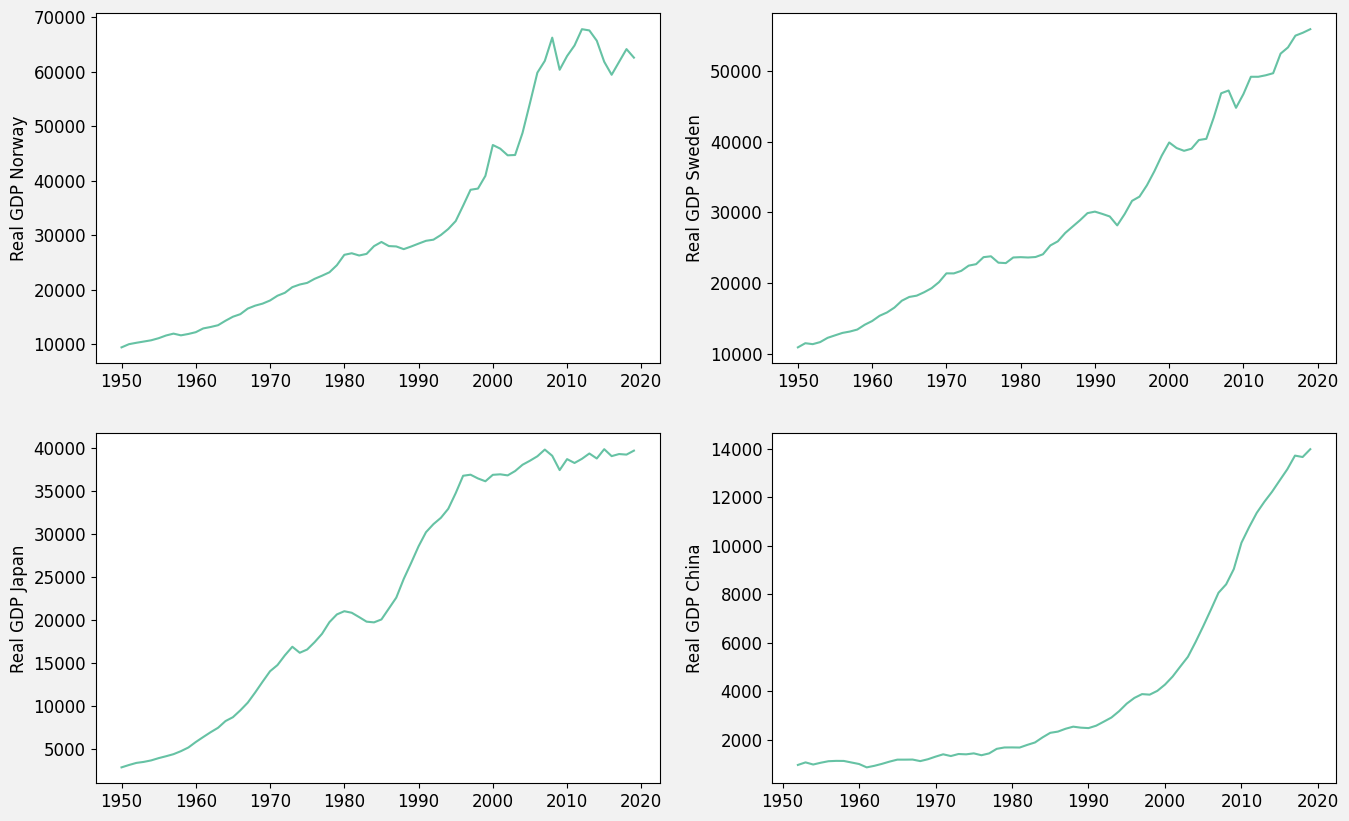

In [79]:
fig, ax = plt.subplots(2, 2)
ax[0, 0].plot(GDP['Norway'])
ax[0, 1].plot(GDP['Sweden'])
ax[1, 0].plot(GDP['Japan'])
ax[1, 1].plot(GDP['China'])
ax[0, 0].set_ylabel('Real GDP Norway')
ax[0, 1].set_ylabel('Real GDP Sweden')
ax[1, 0].set_ylabel('Real GDP Japan')
ax[1, 1].set_ylabel('Real GDP China')
plt.show()

In [83]:
decades = [x * 10 + 1959 for x in range(7)]
decadePwt = pwt.loc[pwt['year'].isin(decades)].copy()

In [84]:
decadePwt.dropna(subset = ['rgdpe_per_pers'], inplace = True)

<Axes: ylabel='Frequency'>

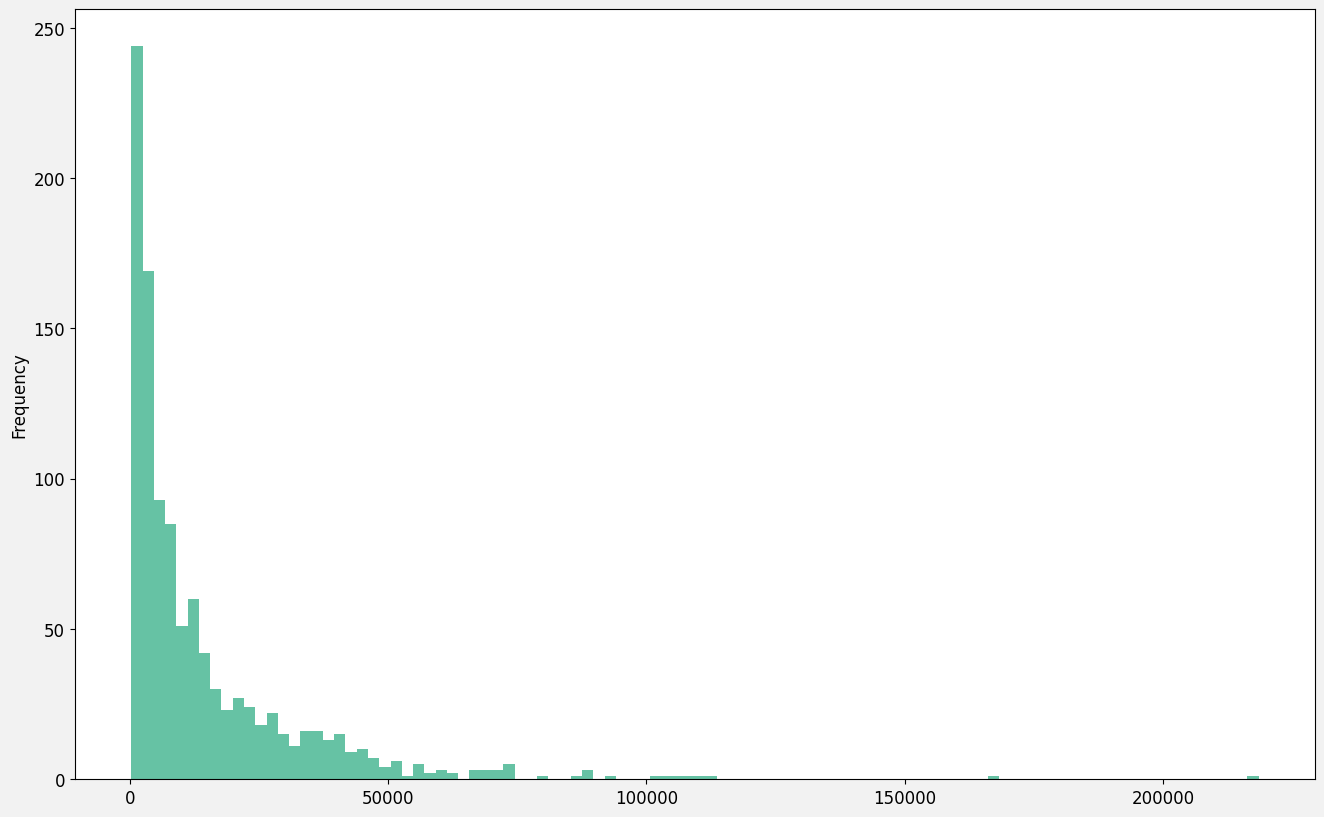

In [85]:
decadePwt['rgdpe_per_pers'].plot(kind = 'hist', bins = 100)

In [92]:
pwtByDecade = decadePwt.groupby('year')

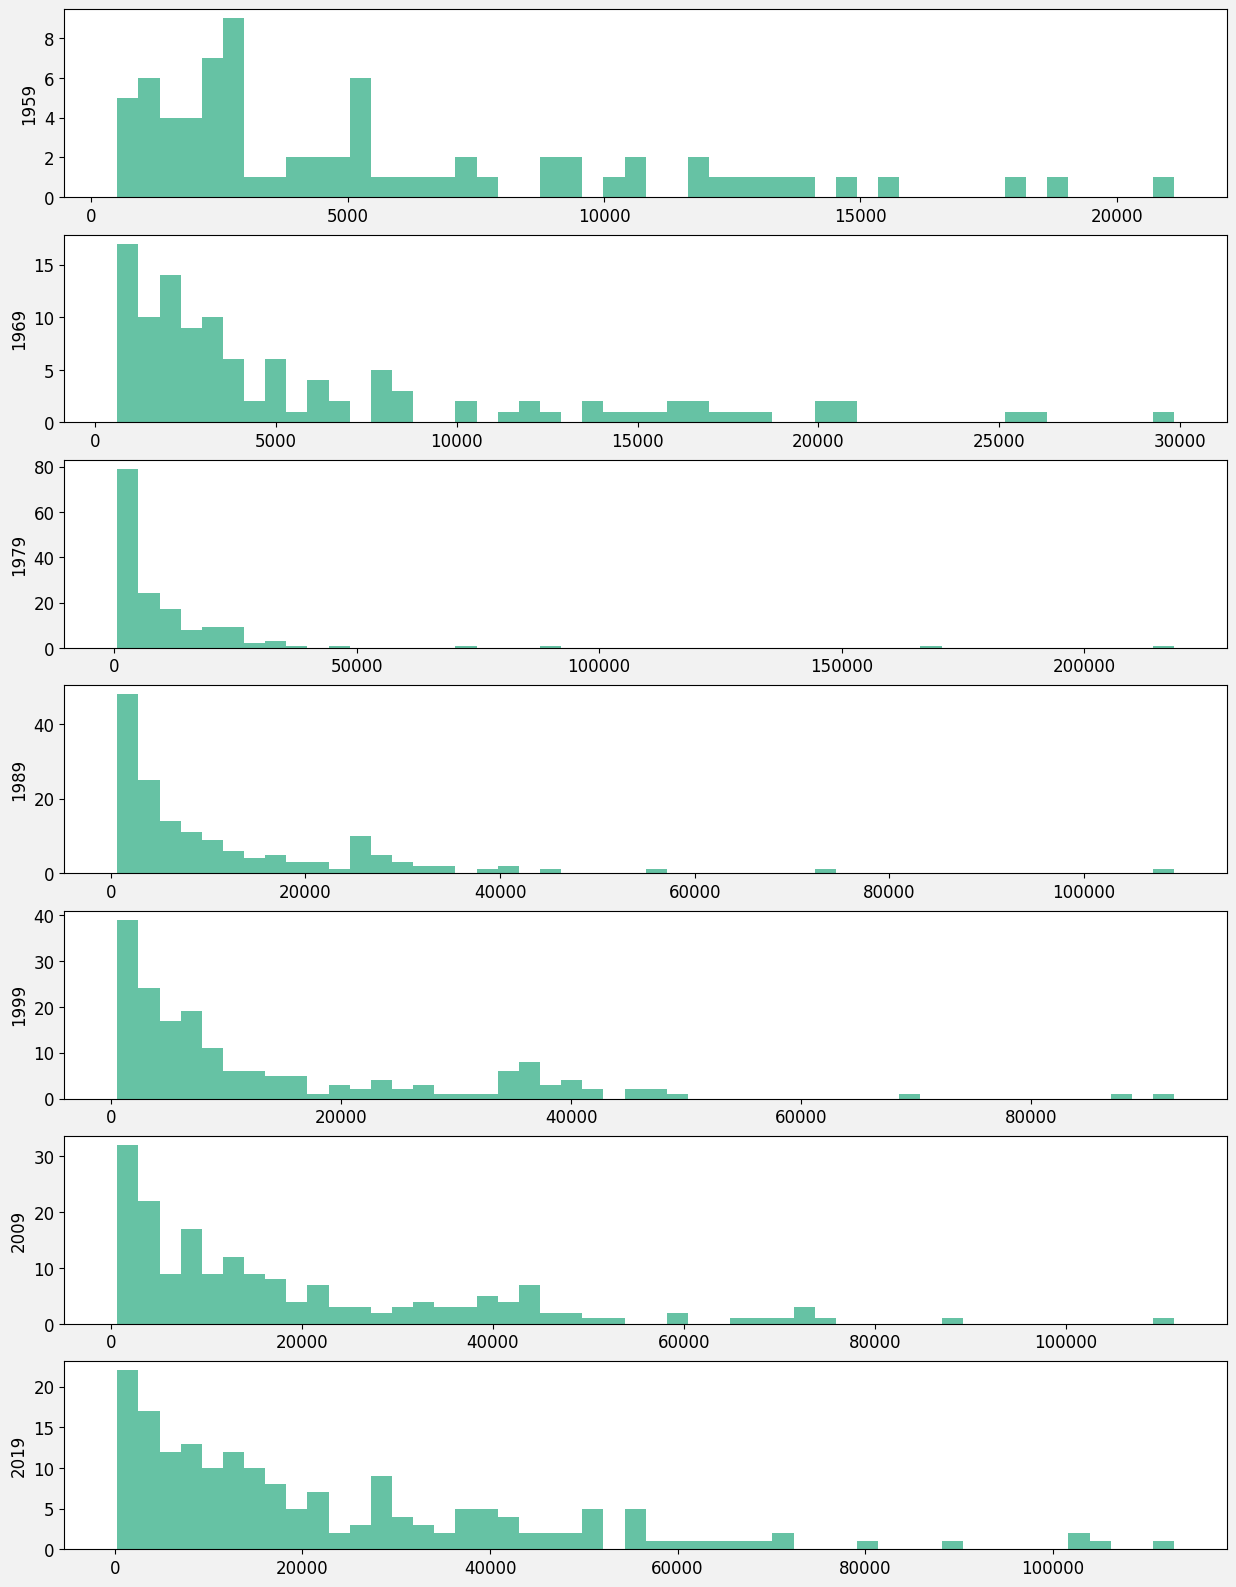

In [93]:
labels = [str(x * 10 + 1959) for x in range(7)]

fig, ax = plt.subplots(7)

for i, decade in enumerate(pwtByDecade):
    ax[i].hist(decade[1]['rgdpe_per_pers'], bins = 50)
    ax[i].set_ylabel(labels[i])

fig.set_size_inches(15, 20)
plt.show()